# Notebook 82 — forward alpha/input audit

This notebook targets the forward alpha/input side rather than the final alpha recursion. It isolates the predicted alpha prior and the TimTrack/Hough alpha measurement, then tests notebook-only swaps against the MATLAB saved run.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_forward_alpha_inputs.py'
OUT = ROOT / 'results' / 'notebook82_forward_alpha_inputs'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_forward_alpha_inputs.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook82_forward_alpha_inputs


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

# Notebook 82 — forward alpha/input audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook targets the forward alpha/input side instead of the final alpha recursion. It isolates two upstream ingredients of the angle channel: the predicted alpha prior (`X_minus[:,1]`) and the TimTrack/Hough alpha measurement.

## Input-side gaps

- Python TimTrack alpha differs from MATLAB geofeature alpha by RMSE 2.7930 deg.
- Python predicted alpha prior differs from MATLAB `X_minus[:,1]` by RMSE 1.2190 deg.
- The resulting Python forward alpha differs from MATLAB forward `X_plus[:,1]` by RMSE 1.2180 deg, and Python final smoothed alpha differs from MATLAB final alpha by RMSE 1.1661 deg.

## Notebook-only forward-input swaps

- Baseline reproduction matches the current run: forward alpha RMSE 1.2180 deg, final alpha RMSE 1.1661 deg, FL RMSE 2.0117 mm.
- Swapping only the measurement series to MATLAB geofeature alpha is the biggest single improvement: forward alpha RMSE drops to

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_forward_alpha_inputs.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook82_summary.md').read_text()))

# Notebook 82 — forward alpha/input audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook targets the forward alpha/input side instead of the final alpha recursion. It isolates two upstream ingredients of the angle channel: the predicted alpha prior (`X_minus[:,1]`) and the TimTrack/Hough alpha measurement.

## Input-side gaps

- Python TimTrack alpha differs from MATLAB geofeature alpha by RMSE 2.7930 deg.
- Python predicted alpha prior differs from MATLAB `X_minus[:,1]` by RMSE 1.2190 deg.
- The resulting Python forward alpha differs from MATLAB forward `X_plus[:,1]` by RMSE 1.2180 deg, and Python final smoothed alpha differs from MATLAB final alpha by RMSE 1.1661 deg.

## Notebook-only forward-input swaps

- Baseline reproduction matches the current run: forward alpha RMSE 1.2180 deg, final alpha RMSE 1.1661 deg, FL RMSE 2.0117 mm.
- Swapping only the measurement series to MATLAB geofeature alpha is the biggest single improvement: forward alpha RMSE drops to 1.2088 deg, final alpha RMSE drops to 0.5470 deg, and FL RMSE drops to 1.1810 mm.
- Swapping only the predicted alpha prior to MATLAB `X_minus[:,1]` also helps, but less: forward alpha RMSE becomes 0.0274 deg, final alpha RMSE 1.0977 deg, and FL RMSE 2.3035 mm.
- Swapping both prior and measurement gives the best notebook-only alpha-channel result: forward alpha RMSE 0.0179 deg, final alpha RMSE 0.0256 deg, and FL RMSE 0.2083 mm.

## Interpretation

- The forward alpha gap is real and upstream. It is not caused by the final backward smoother.
- The measurement side matters more than the prior side on this run. In other words, the current Python TimTrack alpha entering the filter is the bigger contributor to the final angle mismatch.
- The prior still matters, so the full gap is not measurement-only. But the data says the next best direction is to audit how Python produces the per-frame TimTrack alpha that feeds the Kalman update.

## What this means for patching

- We still should not patch raw code yet just to mimic MATLAB outputs.
- A safe next notebook is to target the Python TimTrack alpha production chain directly: candidate selection, persistence, and any geometry/sign conventions before the Kalman update.

- Input metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook82_forward_alpha_inputs/forward_alpha_input_metrics.csv`
- Variant metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook82_forward_alpha_inputs/forward_alpha_variants.csv`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook82_forward_alpha_inputs/forward_alpha_input_traces.png`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook82_forward_alpha_inputs/forward_alpha_variant_summary.png`


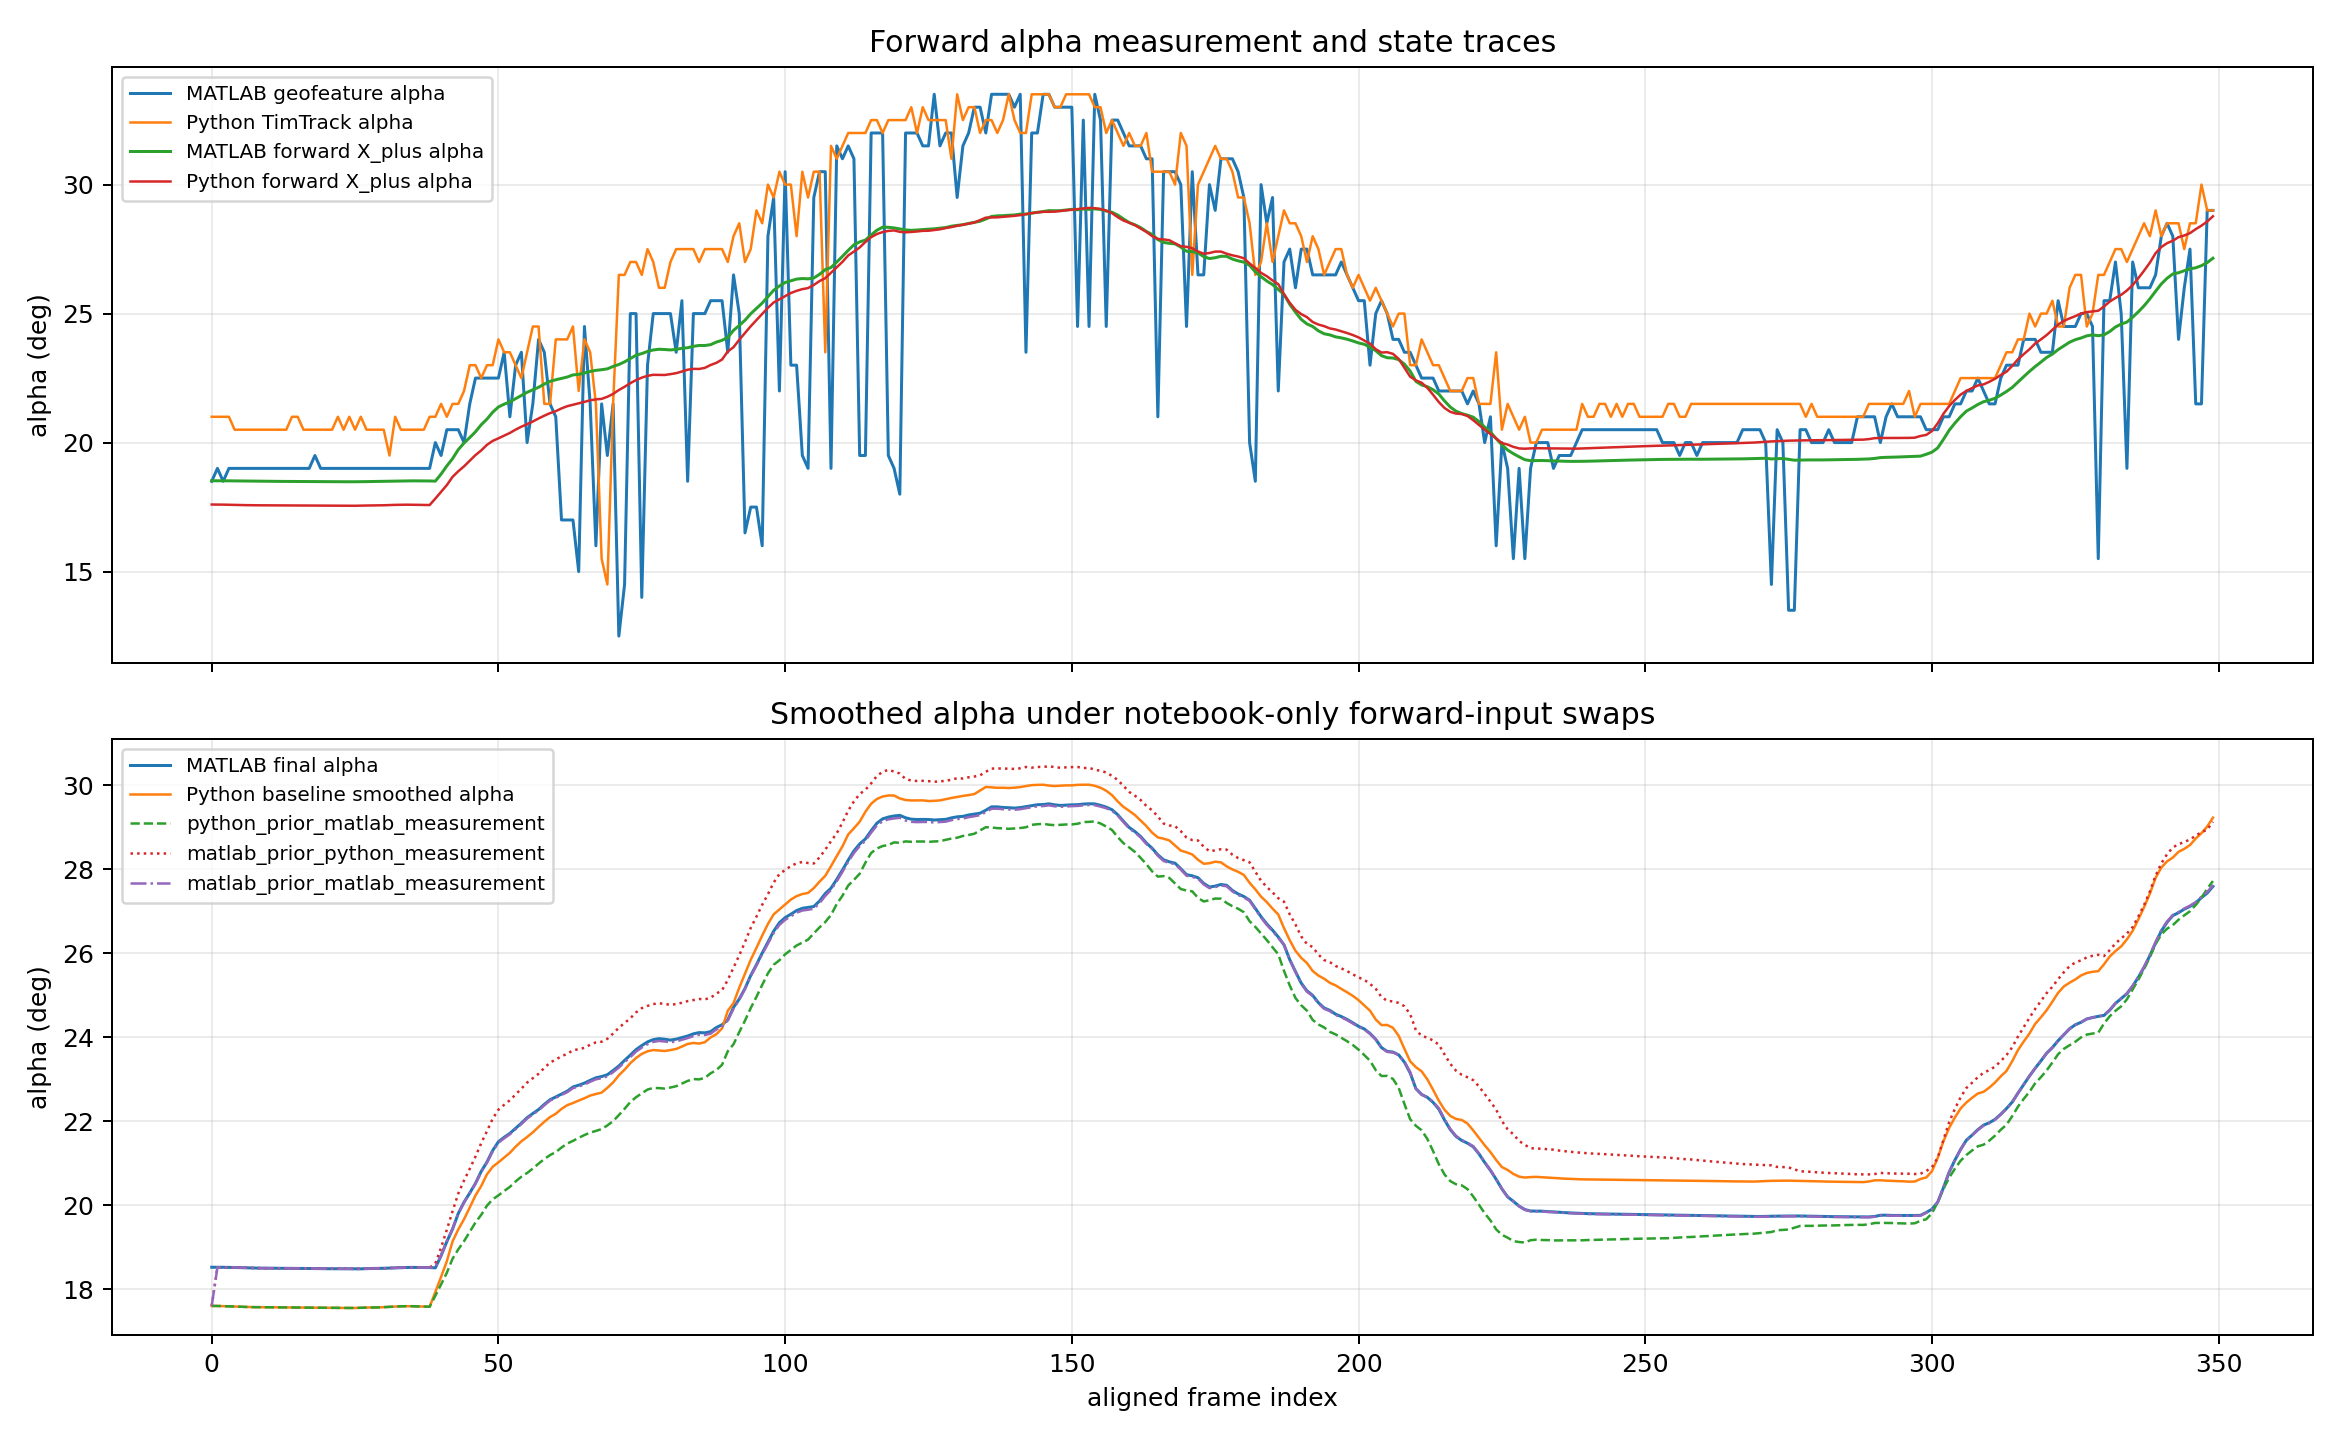

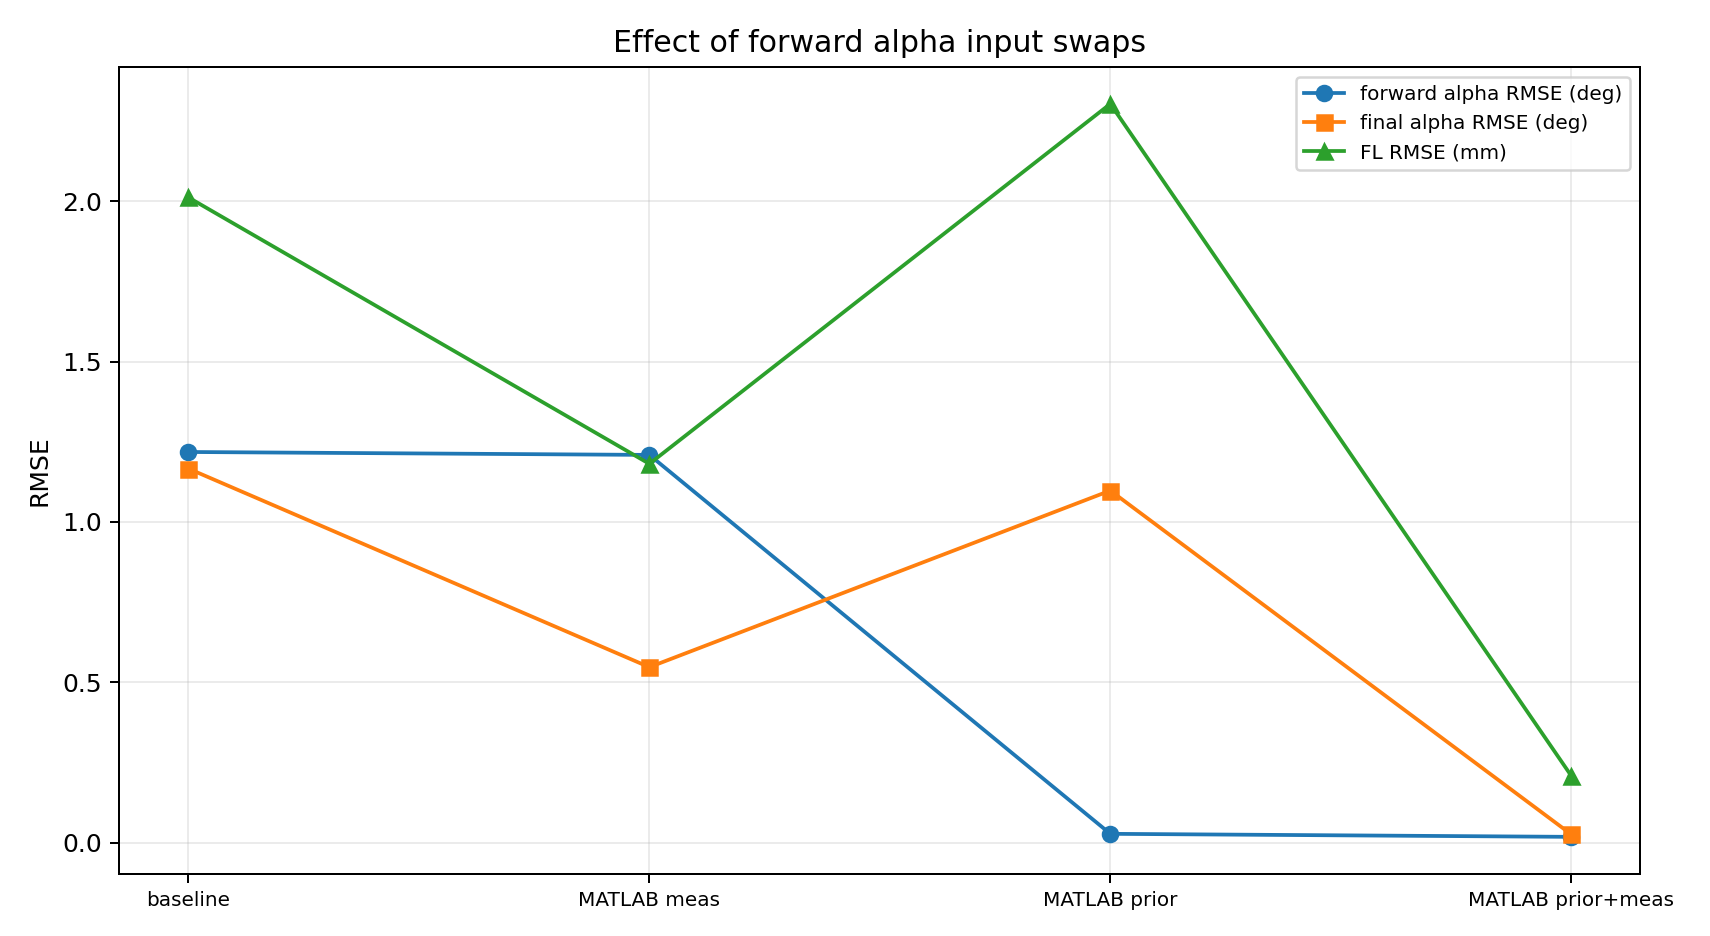

In [4]:
display(Image(filename=str(OUT / 'forward_alpha_input_traces.png')))
display(Image(filename=str(OUT / 'forward_alpha_variant_summary.png')))